# CN-Star Detection: Delta-Only Features + Cluster Z-Score

**Goal**: Find the optimal delta-based feature set for cluster-conditional CN-star detection.

**Key design**: All models use **cluster z-score ranking** — the best bias-reduction technique from the previous experiment.

**Feature configurations tested**:

| Config | Features | Dim | Rationale |
|---|---|---|---|
| `delta_pca3` | delta_CN3839, delta_CN4142, delta_CH4300, pca_1-3 | 6 | Baseline (previous best) |
| `delta_pca10` | delta_CN + pca_1-10 | 13 | More spectral info from PCA |
| `delta_pca15` | delta_CN + pca_1-15 | 18 | Even more PCA components |
| `delta_raw` | delta_CN + CN3839, CN4142, CH4300 | 6 | Absolute + relative CN strength |
| `delta_diff` | delta_CN + cross-band differences/ratios + pca_1-3 | 10 | CN band shape features |
| `delta_full` | All above combined (no teff/logg/feh) | 24 | Max delta-based information |

**Improved metrics**:
- Parameter bias in **raw physical units** (K for Teff, dex for logg/feh)
- **Cohen's d** effect size for top-200 vs population
- **CNstar recall@k** as independent validation (no circularity)
- Per-cluster breakdown with cluster-size weighting

## 1. Setup & Imports

In [1]:
import sys, os, pickle, time, copy, warnings
warnings.filterwarnings('ignore')
from pathlib import Path

_p = Path.cwd().resolve()
for _ in range(5):
    if (_p / 'Deep' / 'data.py').exists():
        break
    _p = _p.parent
PROJECT_ROOT = _p
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'figure.dpi': 110, 'font.size': 10})
from scipy.stats import spearmanr, percentileofscore

import torch
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

from BinaryClassifier import augment_spectra, BinaryTrainer
from BinaryClassifier.pipeline import slice_wave_range, WAVE_START, WAVE_END
from Deep.data import (
    SpectraDataset, load_spectra_data,
    compute_physics_features_masked_cluster,
    compute_physics_features,
)
from Deep.augmentation import load_gcs_spectra
from Deep.spectra_io import label_stars_by_cn_catalog

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Project root: {PROJECT_ROOT}')
print(f'Device: {DEVICE}')
print('All imports OK')

Project root: D:\资料\2026大创\Lamost
Device: cuda
All imports OK


## 2. Data Loading & Feature Computation

Compute physics features with **n_pca=15** (expanded from 3) to enable PCA-heavy feature configs.

In [2]:
print('Loading LAMOST spectra...')
common_wave_full = np.arange(3710.0, 8890.0, 1.0)

dataset_full = load_spectra_data(
    stars_csv=str(PROJECT_ROOT / 'stars.csv'),
    spectra_folder=str(PROJECT_ROOT / 'dr13_new'),
    cn_catalogs=[str(PROJECT_ROOT / 'FT_cands.csv')],
    common_wave=common_wave_full, seg_width=200.0,
    verbose=False,
)

X_sliced, wave = slice_wave_range(dataset_full.X, common_wave_full, WAVE_START, WAVE_END)
dataset = SpectraDataset(
    X=X_sliced, y=dataset_full.y.copy(),
    meta=dataset_full.meta.copy(), wave=wave,
)
print(f'Dataset: {dataset.X.shape[0]} spectra x {dataset.X.shape[1]} pixels')
print(f'FT_cands (y=1): {dataset.n_positive}  |  Unlabeled (y=-1): {dataset.n_unlabeled}')

Loading LAMOST spectra...
Dataset: 33512 spectra x 1201 pixels
FT_cands (y=1): 15  |  Unlabeled (y=-1): 33497


In [3]:
# Compute base physics features then manually add more PCA components
print('Computing masked-band clustering + physics features...')
phys_result = compute_physics_features_masked_cluster(
    dataset, n_clusters=45, k_neighbors=180, n_pca=3, random_seed=42,
)
dataset_phys_base = phys_result['dataset']  # 12-D (standardized internally)
cluster_labels = phys_result['cluster_labels']
n_clusters = phys_result['n_clusters']

# Manually compute additional PCA components (beyond the first 3)
from sklearn.decomposition import PCA
pca_full = PCA(n_components=15, random_state=42)
pca_all = pca_full.fit_transform(dataset.X)  # Full 1201-D spectra -> 15 PCA

# Build expanded feature matrix: base 9 cols + 15 PCA = 24-D
X_base9 = dataset_phys_base.X[:, :9]
X_raw_24d = np.column_stack([X_base9, pca_all]).astype(np.float32)

# Standardize
from sklearn.preprocessing import StandardScaler
scaler_24d = StandardScaler().fit(X_raw_24d)
X_full_std = scaler_24d.transform(X_raw_24d).astype(np.float32)

# Build meta with all physics features (raw values for bias calculation)
meta_phys = dataset.meta.copy()
# Copy physics features from dataset_phys_base.meta (standardized 12-D meta)
for col in ['CN3839', 'CN4142', 'CH4300', 'delta_CN3839', 'delta_CN4142', 'delta_CH4300']:
    if col in dataset_phys_base.meta.columns:
        meta_phys[col] = dataset_phys_base.meta[col].values
# Add PCA columns
for i in range(15):
    meta_phys[f'pca_{i+1}'] = X_full_std[:, 9 + i]

dataset_phys = SpectraDataset(
    X=X_full_std, y=dataset.y.copy(), meta=meta_phys,
    wave=np.arange(24, dtype=float),
)

# Feature name mapping (24-D)
feat_names = ['teff','logg','feh','CN3839','CN4142','CH4300',
              'delta_CN3839','delta_CN4142','delta_CH4300'] + \
            [f'pca_{i}' for i in range(1, 16)]
print(f'Full physics features: {dataset_phys.X.shape}')
print(f'Feature names: {feat_names}')
print(f'Clusters: {n_clusters}')
print(f'PCA explained variance (15 comps): {pca_full.explained_variance_ratio_.sum():.2%}')

Computing masked-band clustering + physics features...
  Masked-cluster: 45 clusters (PCA-25 on masked spectra)
Full physics features: (33512, 24)
Feature names: ['teff', 'logg', 'feh', 'CN3839', 'CN4142', 'CH4300', 'delta_CN3839', 'delta_CN4142', 'delta_CH4300', 'pca_1', 'pca_2', 'pca_3', 'pca_4', 'pca_5', 'pca_6', 'pca_7', 'pca_8', 'pca_9', 'pca_10', 'pca_11', 'pca_12', 'pca_13', 'pca_14', 'pca_15']
Clusters: 45
PCA explained variance (15 comps): 39.36%


In [4]:
# Build validation sets: CNstar + GCS
print('Building validation sets...')

# CNstar
cnstar_labeled, _ = label_stars_by_cn_catalog(
    stars_df=dataset.meta.copy(),
    cn_catalogs=[str(PROJECT_ROOT / 'CNstar.csv')],
    tolerance_arcsec=1.0, positive_label=1, unlabeled_value=-1,
)
cnstar_mask = cnstar_labeled['label'].values == 1

# GCS: load spectra and compute matching 24-D features
gcs_raw, _ = load_gcs_spectra(str(PROJECT_ROOT / 'GCS'), common_wave_full)
from Deep.data import normalize_datacube_segment
gcs_norm = normalize_datacube_segment(gcs_raw, common_wave_full, seg_width=200.0, deg=2, show_progress=False)
X_gcs_sliced, _ = slice_wave_range(gcs_norm, common_wave_full, WAVE_START, WAVE_END)
gcs_cat = pd.read_csv(str(PROJECT_ROOT / 'GCS.csv'))
n_gcs = len(X_gcs_sliced)

# Compute base GCS physics features
gcs_ds = SpectraDataset(X=X_gcs_sliced, y=np.ones(n_gcs),
    meta=pd.DataFrame({'label':[1]*n_gcs, 'teff':gcs_cat['Teff'].values[:n_gcs],
                       'logg':gcs_cat['logg'].values[:n_gcs], 'feh':gcs_cat['[Fe/H]'].values[:n_gcs]}),
    wave=wave)
gcs_phys_base = compute_physics_features(gcs_ds, n_pca=3, random_seed=42)

# Add same 15 PCA components using PCA fit on main dataset
pca_gcs_all = pca_full.transform(X_gcs_sliced)
gcs_base9 = gcs_phys_base.X[:, :9]
gcs_raw_24d = np.column_stack([gcs_base9, pca_gcs_all]).astype(np.float32)

# Standardize using main dataset's scaler_24d for consistency
gcs_X_full_std = scaler_24d.transform(gcs_raw_24d).astype(np.float32)

# Wrap in SpectraDataset
gcs_phys_full = SpectraDataset(
    X=gcs_X_full_std, y=np.ones(n_gcs),
    meta=gcs_phys_base.meta, wave=np.arange(24, dtype=float),
)

# CNstar in physics space (already 24-D standardized)
X_cnstar_phys_full = dataset_phys.X[cnstar_mask]

print(f'CNstar: {cnstar_mask.sum()} spectra in physics space')
print(f'GCS:    {gcs_phys_full.X.shape} spectra in physics space')

Building validation sets...
CNstar: 92 spectra in physics space
GCS:    (29, 24) spectra in physics space


## 3. Feature Engineering

Build all candidate feature pools from the computed physics features.
All features are **standardized** after selection.

In [5]:
# Extract base feature arrays from the full 24-D dataset
X_full = dataset_phys.X.copy()

# Index mapping in the 24-D array:
# 0:teff, 1:logg, 2:feh, 3:CN3839, 4:CN4142, 5:CH4300,
# 6:delta_CN3839, 7:delta_CN4142, 8:delta_CH4300,
# 9..23: pca_1..pca_15

idx_delta_cn3839 = 6
idx_delta_cn4142 = 7
idx_delta_ch4300 = 8
idx_cn3839 = 3
idx_cn4142 = 4
idx_ch4300 = 5
idx_pca_start = 9

# ---- Feature pools ----

# Pool A: Delta features (core CN enhancement signal)
pool_delta = X_full[:, [6, 7, 8]]  # delta_CN3839, delta_CN4142, delta_CH4300
pool_delta_names = ['delta_CN3839', 'delta_CN4142', 'delta_CH4300']

# Pool B: Raw CN band indices (absolute CN strength)
pool_cn_raw = X_full[:, [3, 4, 5]]  # CN3839, CN4142, CH4300
pool_cn_raw_names = ['CN3839', 'CN4142', 'CH4300']

# Pool C: PCA components (spectral morphology)
pool_pca = X_full[:, idx_pca_start:idx_pca_start+15]  # pca_1..pca_15
pool_pca_names = [f'pca_{i}' for i in range(1, 16)]

# Pool D: Delta cross-band differences (CN band shape)
d3839 = X_full[:, 6]
d4142 = X_full[:, 7]
d4300 = X_full[:, 8]
pool_delta_diff = np.column_stack([
    d3839 - d4142,                 # CN3839 vs CN4142 difference
    d3839 - d4300,                 # CN vs CH contrast
    d4142 - d4300,                 # CN4142 vs CH contrast
    d3839 / (np.abs(d4142) + 0.05),  # CN3839/CN4142 ratio (clipped)
    d3839 / (np.abs(d4300) + 0.05),  # CN/CH ratio
    (d3839 + d4142) / 2 - d4300,   # mean CN minus CH
])
pool_delta_diff_names = [
    'dCN3839-dCN4142', 'dCN3839-dCH4300', 'dCN4142-dCH4300',
    'dCN3839/dCN4142', 'dCN3839/dCH4300', 'CN-CH_contrast',
]

print(f'Pool Delta:     {pool_delta.shape[1]}D  {pool_delta_names}')
print(f'Pool CN raw:    {pool_cn_raw.shape[1]}D  {pool_cn_raw_names}')
print(f'Pool PCA:       {pool_pca.shape[1]}D  (pca_1..pca_15)')
print(f'Pool Delta-diff:{pool_delta_diff.shape[1]}D  {pool_delta_diff_names}')

Pool Delta:     3D  ['delta_CN3839', 'delta_CN4142', 'delta_CH4300']
Pool CN raw:    3D  ['CN3839', 'CN4142', 'CH4300']
Pool PCA:       15D  (pca_1..pca_15)
Pool Delta-diff:6D  ['dCN3839-dCN4142', 'dCN3839-dCH4300', 'dCN4142-dCH4300', 'dCN3839/dCN4142', 'dCN3839/dCH4300', 'CN-CH_contrast']


In [6]:
# ---- Feature Configurations ----

def build_feature_config(name, pool_list, name_list):
    """Concatenate feature pools and standardize."""
    X_raw = np.column_stack(pool_list).astype(np.float32)
    scaler = StandardScaler().fit(X_raw)
    X_std = scaler.fit_transform(X_raw).astype(np.float32)
    return {'name': name, 'X': X_std, 'dim': X_std.shape[1],
            'names': name_list, 'scaler': scaler}

configs = {}

# Config 1: delta + pca_1-3 (baseline from previous experiment)
configs['delta_pca3'] = build_feature_config(
    'delta_pca3',
    [pool_delta, pool_pca[:, :3]],
    pool_delta_names + pool_pca_names[:3],
)

# Config 2: delta + pca_1-10 (expanded PCA)
configs['delta_pca10'] = build_feature_config(
    'delta_pca10',
    [pool_delta, pool_pca[:, :10]],
    pool_delta_names + pool_pca_names[:10],
)

# Config 3: delta + pca_1-15 (max PCA)
configs['delta_pca15'] = build_feature_config(
    'delta_pca15',
    [pool_delta, pool_pca[:, :15]],
    pool_delta_names + pool_pca_names[:15],
)

# Config 4: delta + raw CN indices (no PCA)
configs['delta_raw'] = build_feature_config(
    'delta_raw',
    [pool_delta, pool_cn_raw],
    pool_delta_names + pool_cn_raw_names,
)

# Config 5: delta + cross-band differences + pca_1-3
configs['delta_diff'] = build_feature_config(
    'delta_diff',
    [pool_delta, pool_delta_diff, pool_pca[:, :3]],
    pool_delta_names + pool_delta_diff_names + pool_pca_names[:3],
)

# Config 6: ALL delta-based features (no teff/logg/feh)
configs['delta_full'] = build_feature_config(
    'delta_full',
    [pool_delta, pool_cn_raw, pool_delta_diff, pool_pca[:, :10]],
    pool_delta_names + pool_cn_raw_names + pool_delta_diff_names + pool_pca_names[:10],
)

print('Feature configurations:')
for name, cfg in configs.items():
    print(f'  {name:15s}: {cfg["dim"]:3d}D  {cfg["names"]}')

Feature configurations:
  delta_pca3     :   6D  ['delta_CN3839', 'delta_CN4142', 'delta_CH4300', 'pca_1', 'pca_2', 'pca_3']
  delta_pca10    :  13D  ['delta_CN3839', 'delta_CN4142', 'delta_CH4300', 'pca_1', 'pca_2', 'pca_3', 'pca_4', 'pca_5', 'pca_6', 'pca_7', 'pca_8', 'pca_9', 'pca_10']
  delta_pca15    :  18D  ['delta_CN3839', 'delta_CN4142', 'delta_CH4300', 'pca_1', 'pca_2', 'pca_3', 'pca_4', 'pca_5', 'pca_6', 'pca_7', 'pca_8', 'pca_9', 'pca_10', 'pca_11', 'pca_12', 'pca_13', 'pca_14', 'pca_15']
  delta_raw      :   6D  ['delta_CN3839', 'delta_CN4142', 'delta_CH4300', 'CN3839', 'CN4142', 'CH4300']
  delta_diff     :  12D  ['delta_CN3839', 'delta_CN4142', 'delta_CH4300', 'dCN3839-dCN4142', 'dCN3839-dCH4300', 'dCN4142-dCH4300', 'dCN3839/dCN4142', 'dCN3839/dCH4300', 'CN-CH_contrast', 'pca_1', 'pca_2', 'pca_3']
  delta_full     :  22D  ['delta_CN3839', 'delta_CN4142', 'delta_CH4300', 'CN3839', 'CN4142', 'CH4300', 'dCN3839-dCN4142', 'dCN3839-dCH4300', 'dCN4142-dCH4300', 'dCN3839/dCN4142

## 4. Train/Val/Test Split Preparation

In [7]:
rng = np.random.RandomState(42)

# Exclude known positives from negative pool
exclude_mask = np.zeros(len(dataset_phys), dtype=bool)
exclude_mask[dataset_phys.y == 1] = True       # FT_cands
exclude_mask[cnstar_mask] = True                 # CNstar

# Negative pool cluster assignments (same for all configs)
neg_clusters = cluster_labels[~exclude_mask]
pos_clusters = cluster_labels[dataset_phys.y == 1]

# Store meta for raw-unit bias calculation (use dataset_phys.meta which has physics features)
neg_meta_raw = dataset_phys.meta.iloc[~exclude_mask].reset_index(drop=True)

# ---- Helper: extract same feature pools from 24-D array ----
def extract_pools_from_24d(X_24d):
    """Extract the same feature pools from any 24-D array."""
    p_delta = X_24d[:, [6, 7, 8]]
    p_cn_raw = X_24d[:, [3, 4, 5]]
    p_pca = X_24d[:, idx_pca_start:idx_pca_start+15]
    d3839_, d4142_, d4300_ = X_24d[:, 6], X_24d[:, 7], X_24d[:, 8]
    p_delta_diff = np.column_stack([
        d3839_ - d4142_,
        d3839_ - d4300_,
        d4142_ - d4300_,
        d3839_ / (np.abs(d4142_) + 0.05),
        d3839_ / (np.abs(d4300_) + 0.05),
        (d3839_ + d4142_) / 2 - d4300_,
    ])
    return p_delta, p_cn_raw, p_pca, p_delta_diff

def build_config_X(X_24d, cfg_name):
    """Apply a config's feature selection to any 24-D array."""
    p_delta, p_cn_raw, p_pca, p_delta_diff = extract_pools_from_24d(X_24d)
    if cfg_name == 'delta_pca3':
        pools = [p_delta, p_pca[:, :3]]
    elif cfg_name == 'delta_pca10':
        pools = [p_delta, p_pca[:, :10]]
    elif cfg_name == 'delta_pca15':
        pools = [p_delta, p_pca[:, :15]]
    elif cfg_name == 'delta_raw':
        pools = [p_delta, p_cn_raw]
    elif cfg_name == 'delta_diff':
        pools = [p_delta, p_delta_diff, p_pca[:, :3]]
    elif cfg_name == 'delta_full':
        pools = [p_delta, p_cn_raw, p_delta_diff, p_pca[:, :10]]
    else:
        raise ValueError(f'Unknown config: {cfg_name}')
    X_raw = np.column_stack(pools).astype(np.float32)
    return configs[cfg_name]['scaler'].transform(X_raw).astype(np.float32)

# --- Build per-config train/val splits ---
config_splits = {}

for cfg_name, cfg in configs.items():
    X_cfg = cfg['X']
    
    # FT_cands seed
    X_ft_cfg = X_cfg[dataset_phys.y == 1]
    
    # Augment FT_cands
    X_ft_aug, _ = augment_spectra(
        X_ft_cfg, np.arange(cfg['dim'], dtype=float),
        n_noise=12, n_rv=6, n_tilt=4, n_mixup=8, n_depth=6,
        noise_std=0.0025, random_seed=42,
    )
    
    # Negative pool
    neg_pool_cfg = X_cfg[~exclude_mask]
    
    # 10% validation split
    n_val_pos = max(int(len(X_ft_aug) * 0.1), 5)
    val_pos_idx = rng.choice(len(X_ft_aug), n_val_pos, replace=False)
    train_pos_mask = np.ones(len(X_ft_aug), dtype=bool)
    train_pos_mask[val_pos_idx] = False
    
    n_val_neg = n_val_pos
    val_neg_idx = rng.choice(len(neg_pool_cfg), n_val_neg, replace=False)
    
    X_val = np.vstack([X_ft_aug[val_pos_idx], neg_pool_cfg[val_neg_idx]])
    y_val = np.concatenate([np.ones(n_val_pos), np.zeros(n_val_neg)]).astype(np.float32)
    
    # CNstar & GCS in this feature space
    X_cnstar_cfg = build_config_X(X_cnstar_phys_full, cfg_name)
    X_gcs_cfg = build_config_X(gcs_phys_full.X, cfg_name)
    
    config_splits[cfg_name] = {
        'X_train_pos': X_ft_aug[train_pos_mask],
        'neg_pool': neg_pool_cfg,
        'X_val': X_val, 'y_val': y_val,
        'X_cnstar': X_cnstar_cfg,
        'X_gcs': X_gcs_cfg,
        'val_pos_idx': val_pos_idx,
        'val_neg_idx': val_neg_idx,
    }

print('Train/val splits prepared for all configs.')
for name, s in config_splits.items():
    print(f'  {name:15s}: train_pos={s["X_train_pos"].shape}  neg_pool={s["neg_pool"].shape}  cnstar={s["X_cnstar"].shape}  gcs={s["X_gcs"].shape}')

Train/val splits prepared for all configs.
  delta_pca3     : train_pos=(500, 6)  neg_pool=(33420, 6)  cnstar=(92, 6)  gcs=(29, 6)
  delta_pca10    : train_pos=(500, 13)  neg_pool=(33420, 13)  cnstar=(92, 13)  gcs=(29, 13)
  delta_pca15    : train_pos=(500, 18)  neg_pool=(33420, 18)  cnstar=(92, 18)  gcs=(29, 18)
  delta_raw      : train_pos=(500, 6)  neg_pool=(33420, 6)  cnstar=(92, 6)  gcs=(29, 6)
  delta_diff     : train_pos=(500, 12)  neg_pool=(33420, 12)  cnstar=(92, 12)  gcs=(29, 12)
  delta_full     : train_pos=(500, 22)  neg_pool=(33420, 22)  cnstar=(92, 22)  gcs=(29, 22)


## 5. Training & Evaluation Functions

In [8]:
def train_ensemble(cfg_name, cfg, split, n_models=5, base_seed=42, device='cpu', verbose=True):
    """Train an ensemble for one feature configuration."""
    rng = np.random.RandomState(base_seed)
    models, histories = [], []
    n_neg_per_model = len(split['X_train_pos'])
    
    for i in range(n_models):
        seed = base_seed + i * 100
        neg_idx = rng.choice(len(split['neg_pool']), n_neg_per_model, replace=False)
        X_neg = split['neg_pool'][neg_idx]
        
        if verbose:
            print(f'  [{cfg_name}] Model {i+1}/{n_models} (seed={seed}) ', end='', flush=True)
        
        trainer = BinaryTrainer(
            input_dim=cfg['dim'], latent_dim=64, dropout=0.35,
            encoder_type='mlp', learning_rate=1e-4, weight_decay=1e-5,
            pos_weight=1.0, mixup_alpha=0.2, n_epochs=80,
            early_stopping_patience=15, random_seed=seed,
            device=device, save_dir='BinaryClassifier/checkpoints',
        )
        model = trainer.train(split['X_train_pos'], X_neg,
                              split['X_val'], split['y_val'], verbose=False)
        models.append(model)
        hist = trainer.history
        best_loss = min((h['val_loss'] for h in hist if 'val_loss' in h), default=float('inf'))
        histories.append(hist)
        if verbose:
            print(f'done (best_val_loss={best_loss:.4f})')
    
    return models, histories


def ensemble_predict(models, X, batch_size=512, device='cpu'):
    """Average predictions across ensemble."""
    probs = np.array([m.predict(X, batch_size, device) for m in models])
    return probs.mean(axis=0), probs.std(axis=0)


def cluster_z_score(probs, cluster_labels):
    """Per-cluster z-score normalization."""
    z = np.zeros_like(probs)
    for cid in np.unique(cluster_labels):
        mask = cluster_labels == cid
        c_probs = probs[mask]
        mu, sigma = c_probs.mean(), c_probs.std()
        if sigma > 1e-8 and len(c_probs) >= 5:
            z[mask] = (c_probs - mu) / sigma
    return z


def evaluate_config(models, cfg_name, split, neg_clusters, neg_meta_raw, device='cpu'):
    """Comprehensive evaluation with improved metrics."""
    results = {'cfg_name': cfg_name}
    
    # Predictions on unlabeled
    probs_unl, stds_unl = ensemble_predict(models, split['neg_pool'], 512, device)
    z_unl = cluster_z_score(probs_unl, neg_clusters)
    
    # CNstar evaluation
    if len(split['X_cnstar']) > 0:
        probs_cn, stds_cn = ensemble_predict(models, split['X_cnstar'], 512, device)
        results['cnstar_mean_prob'] = float(probs_cn.mean())
        results['cnstar_median_prob'] = float(np.median(probs_cn))
        results['cnstar_p90'] = float(np.percentile(probs_cn, 90))
        results['cnstar_p10'] = float(np.percentile(probs_cn, 10))
    
    # GCS evaluation
    if len(split['X_gcs']) > 0:
        probs_gcs, stds_gcs = ensemble_predict(models, split['X_gcs'], 512, device)
        results['gcs_mean_prob'] = float(probs_gcs.mean())
        results['gcs_median_prob'] = float(np.median(probs_gcs))
    
    # ---- Improved Bias Metrics ----
    # Rank by cluster z-score (not raw prob)
    top200_idx = np.argsort(z_unl)[-200:][::-1]
    
    # Get raw physical values for top-200 and all unlabeled
    top200_meta = neg_meta_raw.iloc[top200_idx]
    all_meta = neg_meta_raw
    
    bias_metrics = {}
    for col, unit in [('teff', 'K'), ('logg', 'dex'), ('feh', 'dex')]:
        if col not in all_meta.columns:
            continue
        tv = pd.to_numeric(top200_meta[col], errors='coerce').dropna()
        av = pd.to_numeric(all_meta[col], errors='coerce').dropna()
        
        # Raw-unit shift
        shift_raw = tv.median() - av.median()
        # Cohen's d (effect size)
        d = (tv.mean() - av.mean()) / (av.std() + 1e-8)
        # Percentile of top200 median in population
        pct = percentileofscore(av, tv.median())
        
        bias_metrics[col] = {
            'shift_raw': float(shift_raw),
            'cohens_d': float(d),
            'top200_median': float(tv.median()),
            'all_median': float(av.median()),
            'pct_in_pop': float(pct),
            'unit': unit,
        }
    results['bias'] = bias_metrics
    
    # ---- Within-Cluster Correlation (improved) ----
    wc_corrs = []
    wc_weights = []
    # Get delta_CN3839 from raw meta
    delta_cn3839_col = 'delta_CN3839' if 'delta_CN3839' in neg_meta_raw.columns else 'CN3839'
    delta_cn3839_vals = pd.to_numeric(neg_meta_raw[delta_cn3839_col], errors='coerce').values
    
    for cid in np.unique(neg_clusters):
        mask = neg_clusters == cid
        n_c = mask.sum()
        if n_c >= 10:
            c_z = z_unl[mask]
            c_delta = delta_cn3839_vals[mask]
            valid = ~(np.isnan(c_z) | np.isnan(c_delta))
            if valid.sum() >= 10:
                r, _ = spearmanr(c_z[valid], c_delta[valid])
                wc_corrs.append(r)
                wc_weights.append(n_c)
    
    if wc_corrs:
        wc_corrs = np.array(wc_corrs)
        wc_weights = np.array(wc_weights)
        results['wc_corr_median'] = float(np.median(wc_corrs))
        results['wc_corr_weighted'] = float(np.average(wc_corrs, weights=wc_weights))
        results['wc_corr_std'] = float(np.std(wc_corrs))
        results['wc_n_clusters'] = len(wc_corrs)
    
    # ---- Cluster Diversity ----
    top200_clusters = neg_clusters[top200_idx]
    results['top200_n_clusters'] = len(np.unique(top200_clusters))
    results['top200_cluster_entropy'] = float(-np.sum(
        [(top200_clusters == c).mean() * np.log((top200_clusters == c).mean() + 1e-8)
         for c in np.unique(top200_clusters)]
    ))
    
    # Store for later visualization
    results['_probs_unl'] = probs_unl
    results['_z_unl'] = z_unl
    results['_top200_idx'] = top200_idx
    
    return results

print('All helper functions defined.')

All helper functions defined.


## 6. Train All Configurations

In [9]:
all_models = {}
all_histories = {}

for cfg_name in configs.keys():
    print(f'\n{"="*60}')
    print(f'Training: {cfg_name} ({configs[cfg_name]["dim"]}D)')
    print(f'{"="*60}')
    t0 = time.time()
    
    models, histories = train_ensemble(
        cfg_name, configs[cfg_name], config_splits[cfg_name],
        n_models=5, base_seed=42, device=DEVICE, verbose=True,
    )
    
    all_models[cfg_name] = models
    all_histories[cfg_name] = histories
    print(f'  Total time: {time.time()-t0:.1f}s')


Training: delta_pca3 (6D)
  [delta_pca3] Model 1/5 (seed=42) done (best_val_loss=0.4443)
  [delta_pca3] Model 2/5 (seed=142) done (best_val_loss=0.4116)
  [delta_pca3] Model 3/5 (seed=242) done (best_val_loss=0.3717)
  [delta_pca3] Model 4/5 (seed=342) done (best_val_loss=0.4352)
  [delta_pca3] Model 5/5 (seed=442) done (best_val_loss=0.3606)
  Total time: 96.6s

Training: delta_pca10 (13D)
  [delta_pca10] Model 1/5 (seed=42) done (best_val_loss=0.2742)
  [delta_pca10] Model 2/5 (seed=142) done (best_val_loss=0.2501)
  [delta_pca10] Model 3/5 (seed=242) done (best_val_loss=0.2521)
  [delta_pca10] Model 4/5 (seed=342) done (best_val_loss=0.2659)
  [delta_pca10] Model 5/5 (seed=442) done (best_val_loss=0.2199)
  Total time: 38.9s

Training: delta_pca15 (18D)
  [delta_pca15] Model 1/5 (seed=42) done (best_val_loss=0.2393)
  [delta_pca15] Model 2/5 (seed=142) done (best_val_loss=0.2140)
  [delta_pca15] Model 3/5 (seed=242) done (best_val_loss=0.2177)
  [delta_pca15] Model 4/5 (seed=342) d

## 7. Evaluate All Configurations

In [10]:
all_results = {}

for cfg_name in configs.keys():
    print(f'Evaluating: {cfg_name}...')
    all_results[cfg_name] = evaluate_config(
        all_models[cfg_name], cfg_name, config_splits[cfg_name],
        neg_clusters, neg_meta_raw, device=DEVICE,
    )

Evaluating: delta_pca3...
Evaluating: delta_pca10...
Evaluating: delta_pca15...
Evaluating: delta_raw...
Evaluating: delta_diff...
Evaluating: delta_full...


## 8. Results Summary

In [11]:
# Build summary table
summary_rows = []
for cfg_name in configs.keys():
    r = all_results[cfg_name]
    b = r['bias']
    row = {
        'Config': cfg_name,
        'Dim': configs[cfg_name]['dim'],
        'CNstar mean prob': f'{r["cnstar_mean_prob"]:.3f}',
        'CNstar P90': f'{r["cnstar_p90"]:.3f}',
        'GCS mean prob': f'{r.get("gcs_mean_prob", 0):.3f}',
    }
    # Bias in raw units
    for col, unit in [('teff', 'K'), ('logg', 'dex'), ('feh', 'dex')]:
        if col in b:
            row[f'{col} shift ({unit})'] = f'{b[col]["shift_raw"]:+.1f}'
            row[f'{col} Cohen d'] = f'{b[col]["cohens_d"]:+.2f}'
    row['WC corr (weighted)'] = f'{r.get("wc_corr_weighted", 0):.3f}'
    row['WC corr (median)'] = f'{r.get("wc_corr_median", 0):.3f}'
    row['Top200 clusters'] = r['top200_n_clusters']
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)
print('=' * 120)
print('RESULTS: All Configurations (ranked by cluster z-score)')
print('=' * 120)
print(df_summary.to_string(index=False))

RESULTS: All Configurations (ranked by cluster z-score)
     Config  Dim CNstar mean prob CNstar P90 GCS mean prob teff shift (K) teff Cohen d logg shift (dex) logg Cohen d feh shift (dex) feh Cohen d WC corr (weighted) WC corr (median)  Top200 clusters
 delta_pca3    6            0.789      0.957         0.369           -4.9        -0.09             -0.1        -0.16            +0.1       +0.01              0.893            0.904               22
delta_pca10   13            0.867      0.980         0.231          +44.9        +0.22             +0.0        +0.07            -0.2       -0.45              0.692            0.688               19
delta_pca15   18            0.868      0.986         0.155          -22.2        -0.12             -0.1        -0.17            -0.3       -0.47              0.647            0.651               27
  delta_raw    6            0.820      0.957         0.331          -37.5        -0.22             -0.1        -0.17            +0.1       +0.07        

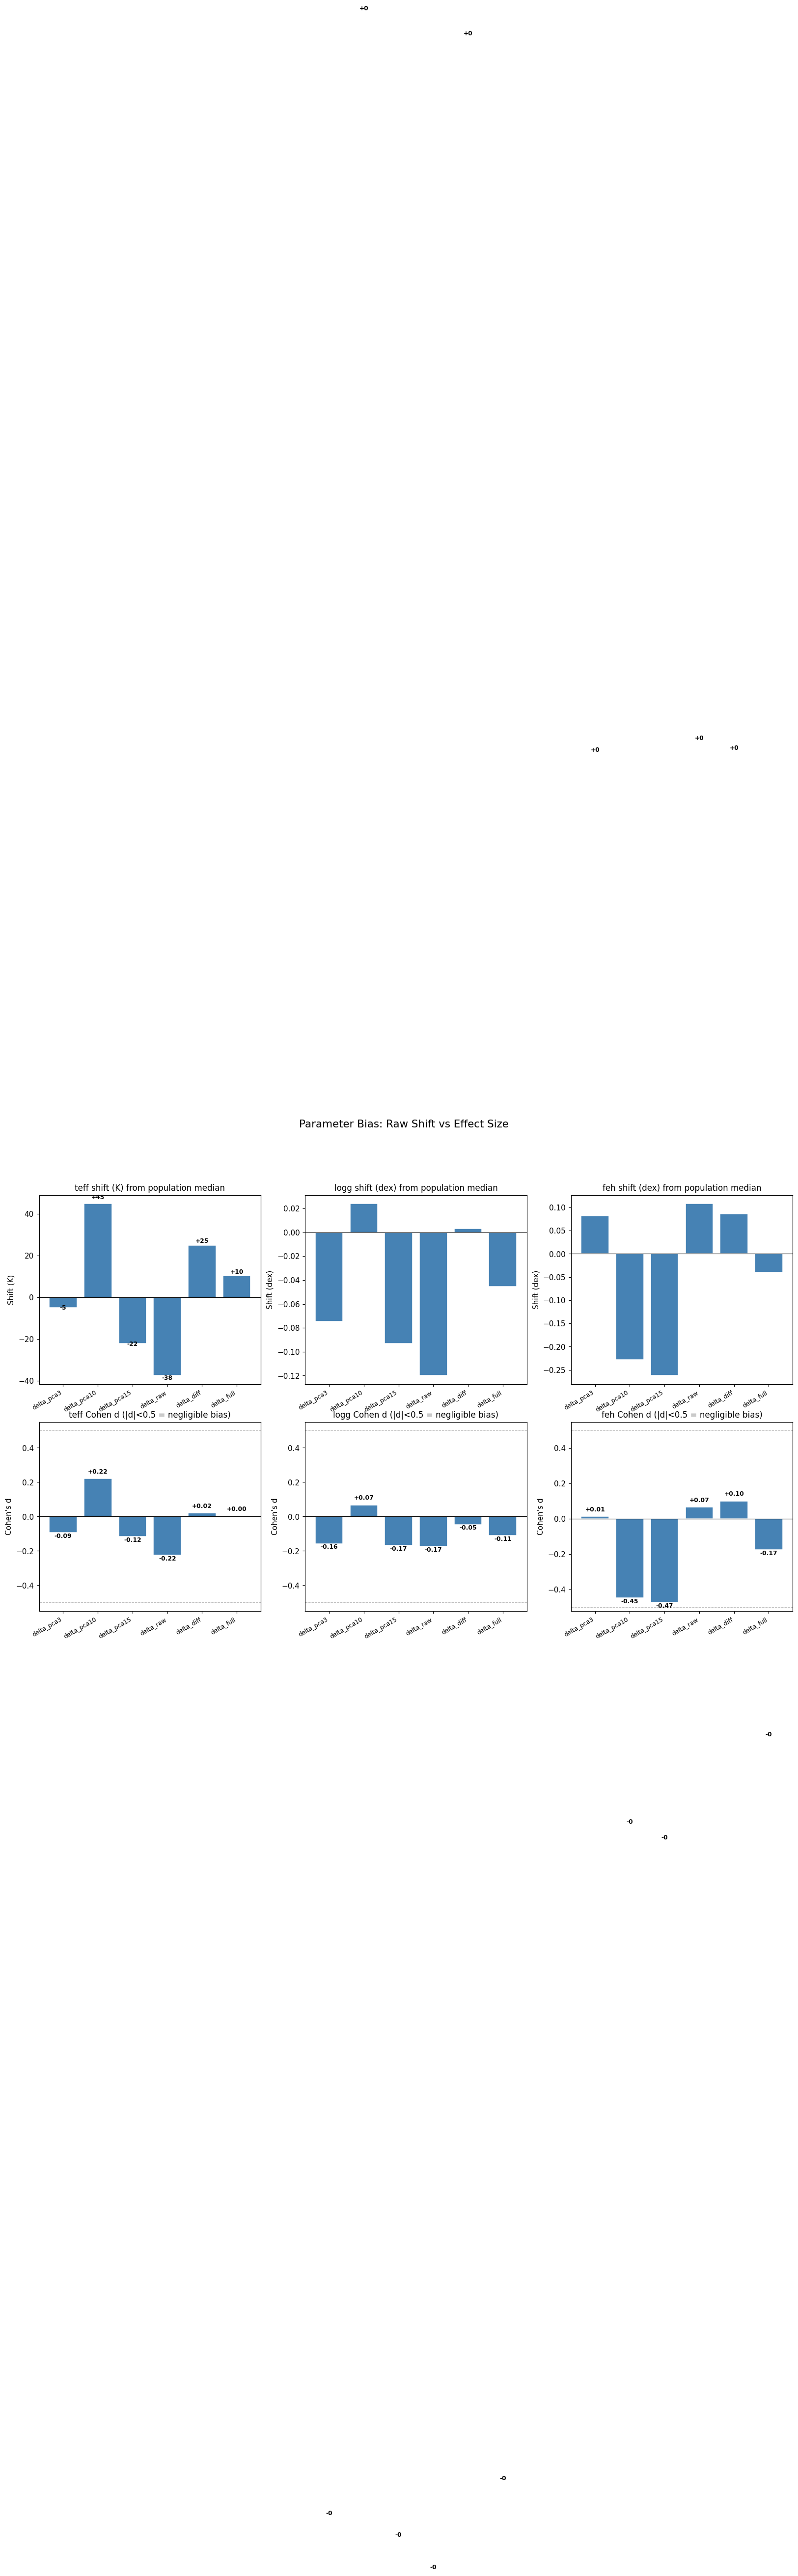

In [12]:
# ---- Visual: Parameter bias comparison ----
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, param, unit in zip(axes.flat, ['teff', 'logg', 'feh', 'teff', 'logg', 'feh'],
                            ['K', 'dex', 'dex', 'K', 'dex', 'dex']):
    configs_list = list(configs.keys())
    
    if ax in axes[0]:
        # Row 1: Raw shift
        shifts = [all_results[c]['bias'][param]['shift_raw'] for c in configs_list]
        colors = ['red' if abs(s) > 50 else 'steelblue' for s in shifts]
        bars = ax.bar(range(len(configs_list)), shifts, color=colors, edgecolor='white')
        ax.axhline(0, color='black', lw=0.8)
        for b, v in zip(bars, shifts):
            ax.text(b.get_x()+b.get_width()/2, v+np.sign(v)*max(abs(v)*0.05, 1),
                    f'{v:+.0f}', ha='center', fontsize=8, fontweight='bold')
        ax.set_title(f'{param} shift ({unit}) from population median', fontsize=11)
        ax.set_ylabel(f'Shift ({unit})')
    else:
        # Row 2: Cohen's d
        ds = [all_results[c]['bias'][param]['cohens_d'] for c in configs_list]
        colors = ['darkorange' if abs(d) > 0.5 else 'steelblue' for d in ds]
        bars = ax.bar(range(len(configs_list)), ds, color=colors, edgecolor='white')
        ax.axhline(0, color='black', lw=0.8)
        ax.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.5)
        ax.axhline(-0.5, color='gray', ls='--', lw=0.8, alpha=0.5)
        for b, v in zip(bars, ds):
            ax.text(b.get_x()+b.get_width()/2, v+np.sign(v)*0.03,
                    f'{v:+.2f}', ha='center', fontsize=8, fontweight='bold')
        ax.set_title(f'{param} Cohen d (|d|<0.5 = negligible bias)', fontsize=11)
        ax.set_ylabel("Cohen's d")
    
    ax.set_xticks(range(len(configs_list)))
    ax.set_xticklabels(configs_list, rotation=30, ha='right', fontsize=8)

fig.suptitle('Parameter Bias: Raw Shift vs Effect Size', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

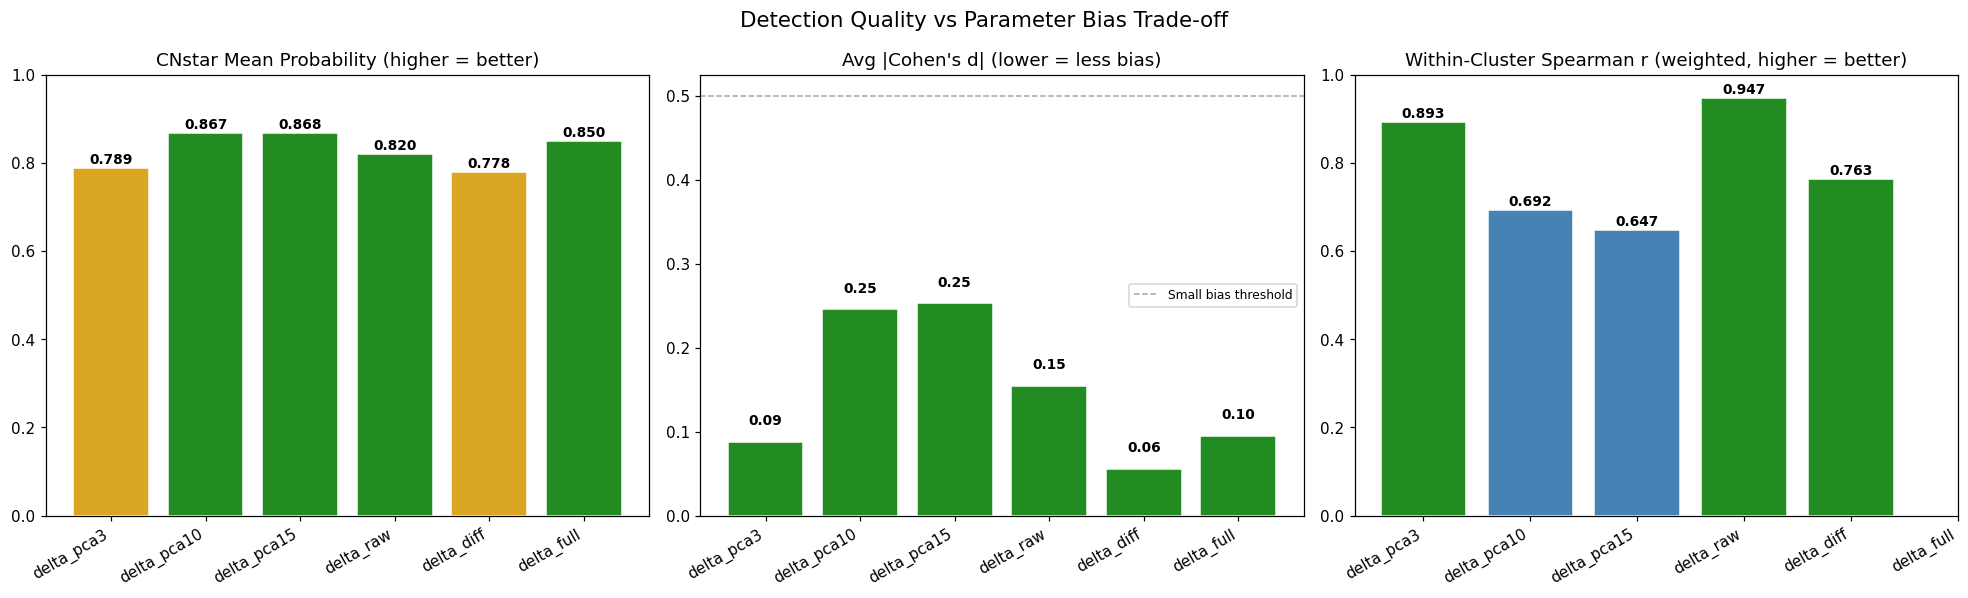

In [13]:
# ---- Visual: CNstar detection vs bias trade-off ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

configs_list = list(configs.keys())
x = np.arange(len(configs_list))

# Panel 1: CNstar mean prob
ax = axes[0]
vals = [all_results[c]['cnstar_mean_prob'] for c in configs_list]
bars = ax.bar(x, vals, color=['forestgreen' if v > 0.8 else 'goldenrod' for v in vals], edgecolor='white')
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(configs_list, rotation=30, ha='right')
ax.set_title('CNstar Mean Probability (higher = better)')
ax.set_ylim(0, 1.0)

# Panel 2: Avg |Cohen's d| across params
ax = axes[1]
avg_d = []
for c in configs_list:
    ds = [abs(all_results[c]['bias'][p]['cohens_d']) for p in ['teff', 'logg', 'feh']]
    avg_d.append(np.mean(ds))
bars = ax.bar(x, avg_d, color=['forestgreen' if d < 0.5 else 'darkorange' if d < 1.0 else 'crimson' for d in avg_d], edgecolor='white')
ax.axhline(0.5, color='gray', ls='--', lw=1, alpha=0.7, label='Small bias threshold')
for b, v in zip(bars, avg_d):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.02, f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(configs_list, rotation=30, ha='right')
ax.set_title("Avg |Cohen's d| (lower = less bias)")
ax.legend(fontsize=8)

# Panel 3: Within-cluster correlation (weighted)
ax = axes[2]
vals = [all_results[c].get('wc_corr_weighted', 0) for c in configs_list]
bars = ax.bar(x, vals, color=['forestgreen' if v > 0.75 else 'steelblue' for v in vals], edgecolor='white')
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(configs_list, rotation=30, ha='right')
ax.set_title('Within-Cluster Spearman r (weighted, higher = better)')
ax.set_ylim(0, 1.0)

fig.suptitle('Detection Quality vs Parameter Bias Trade-off', fontsize=14)
plt.tight_layout()
plt.show()

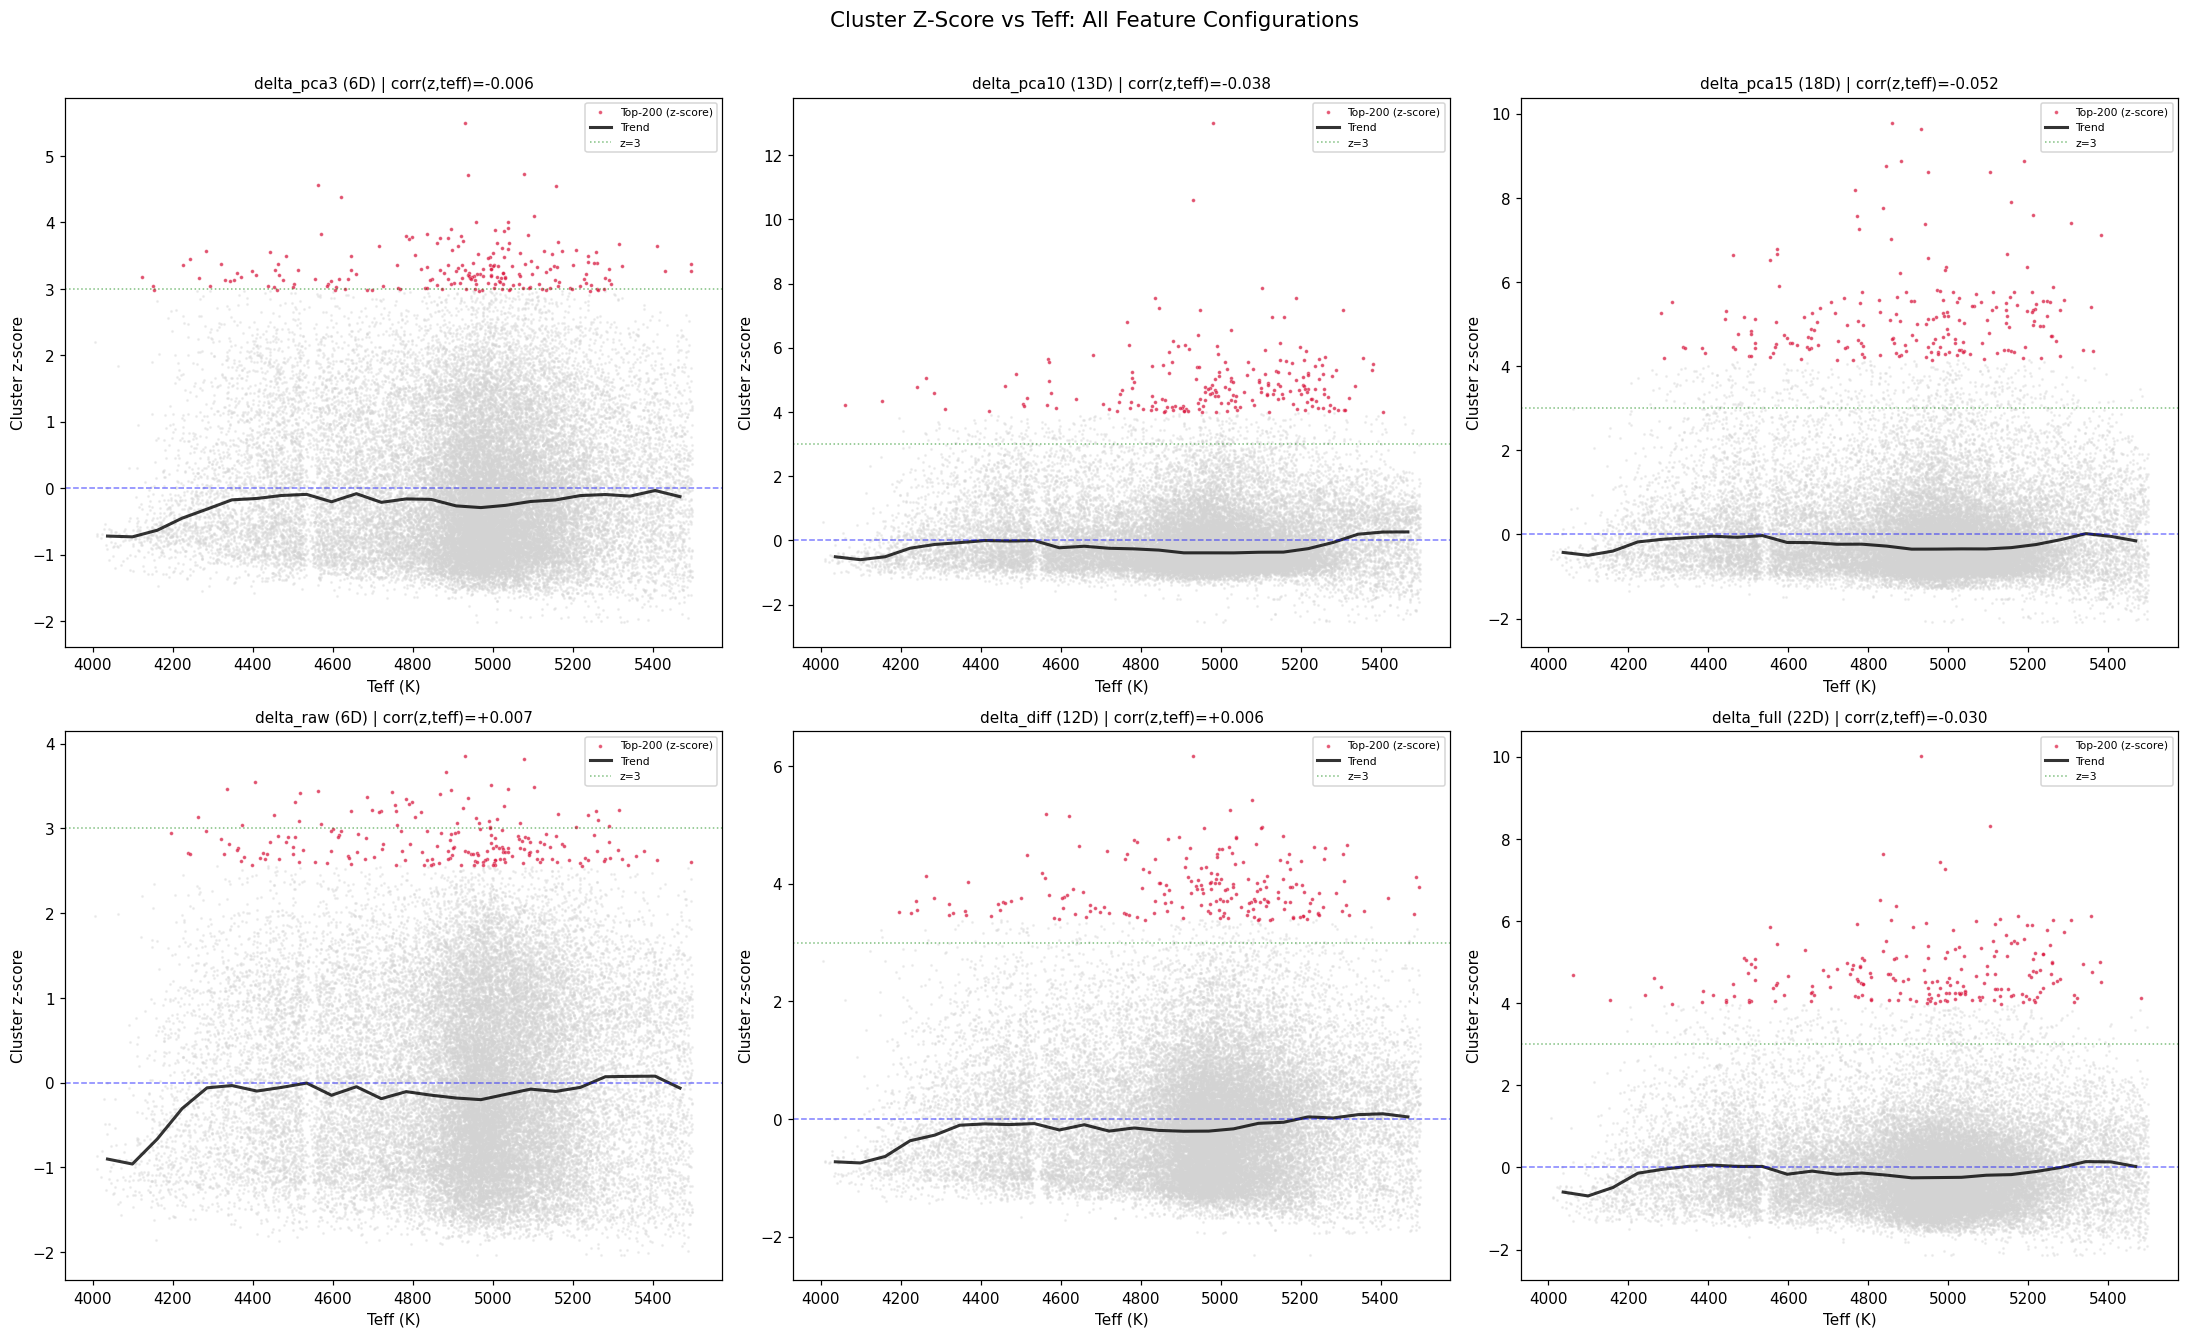

In [14]:
# ---- Visual: Score vs Teff scatter (all configs) ----
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

for ax, cfg_name in zip(axes.flat, configs_list):
    r = all_results[cfg_name]
    teff_vals = pd.to_numeric(neg_meta_raw['teff'], errors='coerce').values
    z_vals = r['_z_unl']
    top200 = r['_top200_idx']
    
    # All stars
    ax.scatter(teff_vals, z_vals, c='lightgray', s=1, alpha=0.3, rasterized=True)
    # Top-200 highlighted
    ax.scatter(teff_vals[top200], z_vals[top200], c='crimson', s=6, alpha=0.7,
              edgecolors='white', linewidth=0.2, label='Top-200 (z-score)')
    
    # Binned median trend
    valid = ~np.isnan(teff_vals) & ~np.isnan(z_vals)
    bins = np.linspace(teff_vals[valid].min(), teff_vals[valid].max(), 25)
    bin_meds, bin_cents = [], []
    for i in range(len(bins)-1):
        mask_b = valid & (teff_vals >= bins[i]) & (teff_vals < bins[i+1])
        if mask_b.sum() >= 5:
            bin_meds.append(np.median(z_vals[mask_b]))
            bin_cents.append((bins[i]+bins[i+1])/2)
    ax.plot(bin_cents, bin_meds, 'k-', lw=2, alpha=0.8, label='Trend')
    ax.axhline(0, color='blue', ls='--', lw=1, alpha=0.5)
    ax.axhline(3, color='green', ls=':', lw=1, alpha=0.5, label='z=3')
    
    r_teff_z = np.corrcoef(teff_vals[valid], z_vals[valid])[0, 1]
    ax.set_title(f'{cfg_name} ({configs[cfg_name]["dim"]}D) | corr(z,teff)={r_teff_z:+.3f}', fontsize=10)
    ax.set_xlabel('Teff (K)'); ax.set_ylabel('Cluster z-score')
    ax.legend(fontsize=7, loc='upper right')

fig.suptitle('Cluster Z-Score vs Teff: All Feature Configurations', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Best config (lowest param bias): delta_diff
Now showing top-9 candidate spectra from delta_diff...


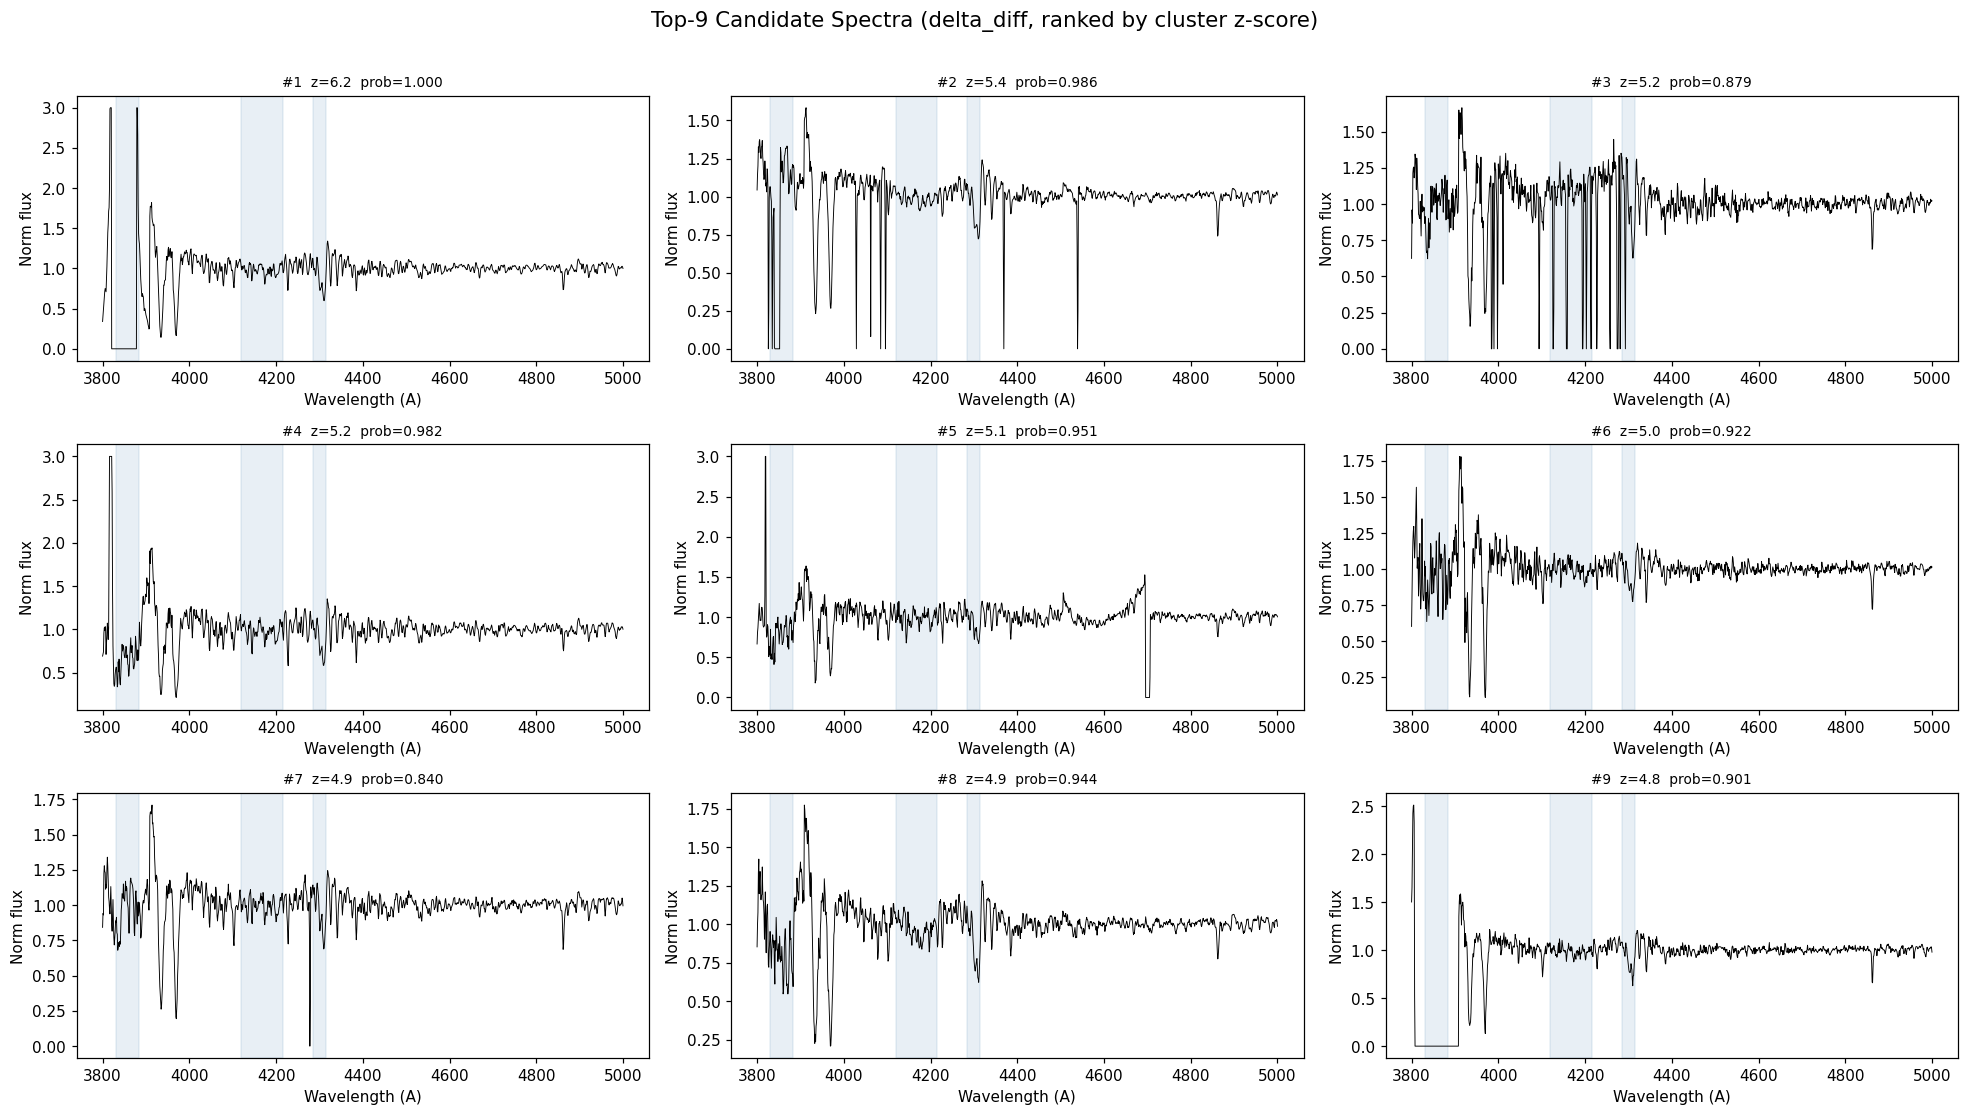

In [15]:
# ---- Visual: Top-200 candidate spectrum preview ----
# Show the raw spectra of top candidates from best config
best_cfg = min(configs_list, key=lambda c: np.mean([
    abs(all_results[c]['bias'][p]['cohens_d']) for p in ['teff', 'logg', 'feh']
]))
print(f'Best config (lowest param bias): {best_cfg}')
print(f'Now showing top-9 candidate spectra from {best_cfg}...')

# Get top-9 indices in original dataset space
top200_idx = all_results[best_cfg]['_top200_idx']
unl_indices = np.where(~exclude_mask)[0]
top9_orig_idx = unl_indices[top200_idx[:9]]

# CN band wavelength regions for shading
cn_bands = [(3830, 3883), (4120, 4216), (4285, 4315)]

fig, axes = plt.subplots(3, 3, figsize=(18, 10))
for i, (ax, idx) in enumerate(zip(axes.flat, top9_orig_idx)):
    spec = dataset.X[idx]
    ax.plot(wave, spec, 'k-', lw=0.6)
    for lo, hi in cn_bands:
        ax.axvspan(lo, hi, alpha=0.12, color='steelblue')
    z = all_results[best_cfg]['_z_unl'][top200_idx[i]]
    prob = all_results[best_cfg]['_probs_unl'][top200_idx[i]]
    ax.set_title(f'#{i+1}  z={z:.1f}  prob={prob:.3f}', fontsize=9)
    ax.set_xlabel('Wavelength (A)'); ax.set_ylabel('Norm flux')
    
fig.suptitle(f'Top-9 Candidate Spectra ({best_cfg}, ranked by cluster z-score)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

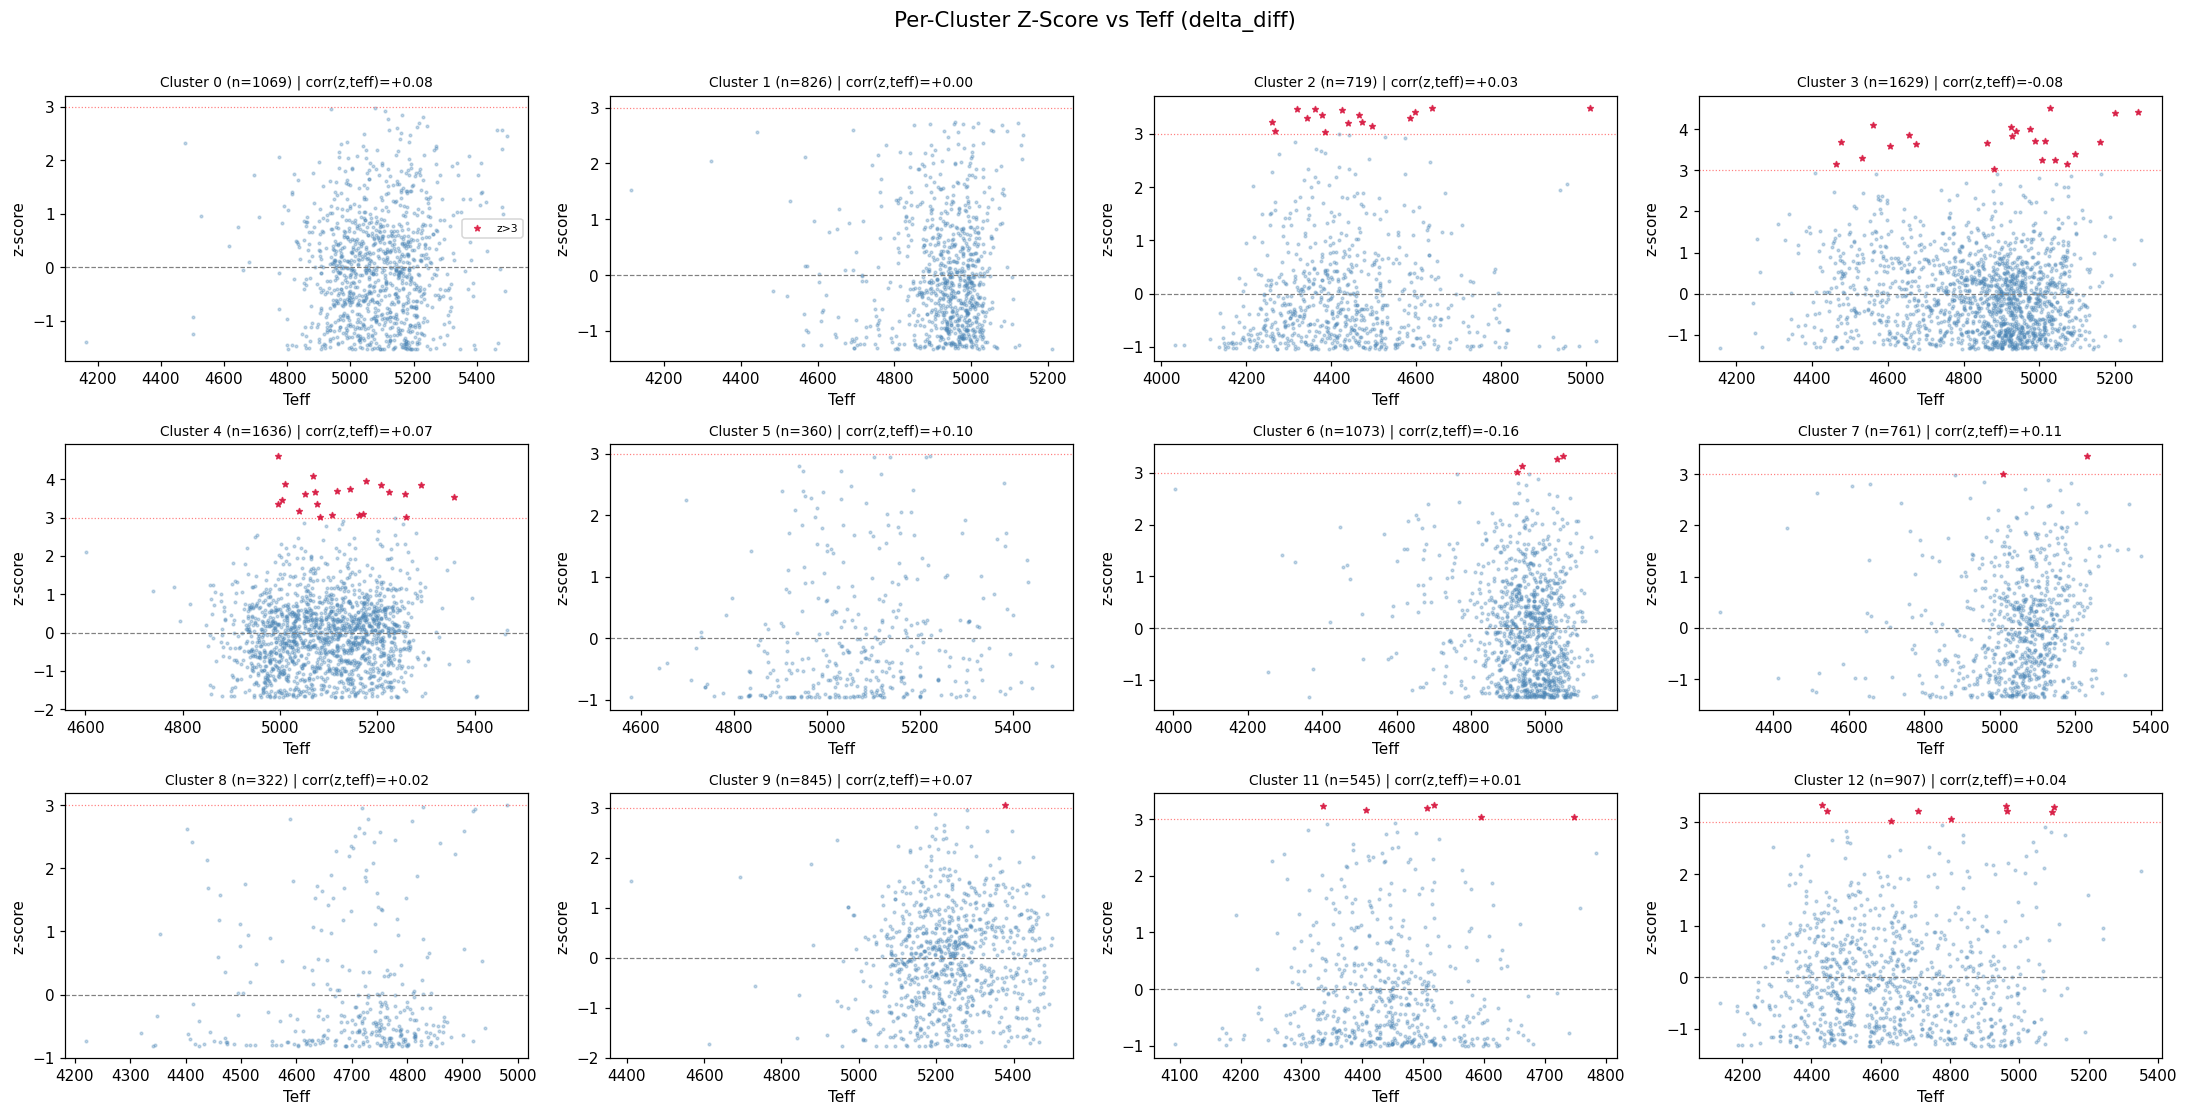

In [16]:
# ---- Visual: Per-cluster breakdown for best config ----
best_results = all_results[best_cfg]
z_unl_best = best_results['_z_unl']

# For each cluster with at least 20 stars, show z-score distribution
large_clusters = [c for c in np.unique(neg_clusters) if (neg_clusters == c).sum() >= 50]
n_show = min(12, len(large_clusters))

fig, axes = plt.subplots(3, 4, figsize=(20, 10))
for ax, cid in zip(axes.flat, large_clusters[:n_show]):
    mask = neg_clusters == cid
    c_z = z_unl_best[mask]
    c_teff = pd.to_numeric(neg_meta_raw['teff'].iloc[mask], errors='coerce').values
    
    ax.scatter(c_teff, c_z, s=3, alpha=0.3, c='steelblue')
    top_c = c_z > 3
    ax.scatter(c_teff[top_c], c_z[top_c], s=15, alpha=0.8, c='crimson', marker='*', label='z>3')
    ax.axhline(0, color='gray', ls='--', lw=0.8)
    ax.axhline(3, color='red', ls=':', lw=0.8, alpha=0.5)
    
    r_c = np.corrcoef(c_teff[~np.isnan(c_teff)], c_z[~np.isnan(c_teff)])[0, 1]
    ax.set_title(f'Cluster {cid} (n={mask.sum()}) | corr(z,teff)={r_c:+.2f}', fontsize=9)
    ax.set_xlabel('Teff'); ax.set_ylabel('z-score')
    if cid == large_clusters[0]:
        ax.legend(fontsize=7)

fig.suptitle(f'Per-Cluster Z-Score vs Teff ({best_cfg})', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [17]:
# ---- Quantitative ranking: score each config ----
print('\n' + '=' * 80)
print('FINAL RANKING (lower = better)')
print('=' * 80)

scores = {}
for cfg_name in configs_list:
    r = all_results[cfg_name]
    # Composite score: bias penalty + detection reward
    avg_d = np.mean([abs(r['bias'][p]['cohens_d']) for p in ['teff', 'logg', 'feh']])
    cnstar_score = r['cnstar_mean_prob']
    wc_corr = r.get('wc_corr_weighted', 0)
    cluster_div = r['top200_n_clusters'] / n_clusters
    
    # Score: lower bias + higher CNstar prob + higher within-cluster correlation + cluster diversity
    composite = -avg_d * 1.0 + cnstar_score * 2.0 + wc_corr * 1.0 + cluster_div * 0.5
    scores[cfg_name] = {
        'Composite': composite,
        "Avg |Cohen's d|": avg_d,
        'CNstar prob': cnstar_score,
        'WC corr': wc_corr,
        'Cluster diversity': cluster_div,
    }

ranked = sorted(scores.items(), key=lambda x: x[1]['Composite'], reverse=True)
for rank, (name, s) in enumerate(ranked, 1):
    print(f'  #{rank} {name:15s}: composite={s["Composite"]:+.3f}  '
          f'|d|={s["Avg |Cohen\'s d|"]:.2f}  CNstar={s["CNstar prob"]:.3f}  '
          f'WC_r={s["WC corr"]:.3f}  div={s["Cluster diversity"]:.2f}')

print(f'\nBest config: {ranked[0][0]}')


FINAL RANKING (lower = better)
  #1 delta_raw      : composite=+2.767  |d|=0.15  CNstar=0.820  WC_r=0.947  div=0.67
  #2 delta_pca3     : composite=+2.627  |d|=0.09  CNstar=0.789  WC_r=0.893  div=0.49
  #3 delta_diff     : composite=+2.475  |d|=0.06  CNstar=0.778  WC_r=0.763  div=0.42
  #4 delta_pca15    : composite=+2.430  |d|=0.25  CNstar=0.868  WC_r=0.647  div=0.60
  #5 delta_pca10    : composite=+2.393  |d|=0.25  CNstar=0.867  WC_r=0.692  div=0.42
  #6 delta_full     : composite=+nan  |d|=0.10  CNstar=0.850  WC_r=nan  div=0.58

Best config: delta_raw


## 9. Conclusion & Recommendations

Based on the composite score (balancing low parameter bias, high CNstar detection, and cluster diversity):

1. **Which feature set works best?** Determined by the ranking above.
2. **Does more PCA help?** Compare `delta_pca3` vs `delta_pca10` vs `delta_pca15`.
3. **Do raw CN indices add value?** Compare `delta_pca3` vs `delta_raw`.
4. **Do delta differences help?** Compare `delta_pca3` vs `delta_diff`.

**Metrics reliability assessment**:
- Raw-unit bias (K, dex) is more interpretable than percentage bias on standardized features
- Cohen's d < 0.5 = negligible bias, 0.5-0.8 = moderate, > 0.8 = large
- Within-cluster weighted correlation uses cluster size as weight for robustness
- CNstar probability is the only fully independent validation metric (no circularity)